---
title: "3D Simulation of Ground and Airborne NSEM Data"
authors:
  - id: devincowan
---

```{admonition} Intermediate notebook
:class: caution
This tutorial focusses on intermediate level functionality within SimPEG. Basic functionality within SimPEG is not discussed in detail, as we assume the user is already familiar. 
```

```{admonition} Medium-weight notebook
:class: caution
Requires moderate computational resources. Run-times may exceed several minutes and require up to 8 GB of available RAM.
```

```{admonition} Prerequisite Tutorials
:class: note
* [2D Simulation of Ground MT and Airborne Tipper Data](fwd_nsem_2d.ipynb)
```

**Keywords:** NSEM, forward simulation, 3D simulation.

</br>

**Summary:** In this tutorial, we use the module [simpeg.electromagnetics.natural_source](xref:simpeg#simpeg.electromagnetics.natural_source) to simulate NSEM data for a 3D problem geometry. Data are simulated and discussed for a variety of transfer functions (data types).

**Learning Objectives:**

- The simulation of 3D NSEM data with SimPEG.
- The data convention SimPEG uses for NSEM data.
- Demonstrating the suite of transfer functions (data types) that can be modeled with SimPEG.
- Understanding what these different transfer functions tell us about the conductivity.

:::{warning} Warning: SimPEG NSEM data convention!
SimPEG uses a universally right-handed coordinate system with X = Easting, Y = Northing and Z positive upward, and a $+i\omega t$ Fourier convention. This in contrast to the Northing-Easting-Down convention that is commonly adopted by the NSEM community.
:::

## Import Modules

Here, we import all of the functionality required to run the notebook for the tutorial exercise. All of the functionality specific to NSEM is imported from [simpeg.electromagnetics.natural_source](xref:simpeg#simpeg.electromagnetics.natural_source). To generate the mesh, we use the [discretize](https://discretize.simpeg.xyz/en/main) package.
We also import some useful utility functions from [simpeg.utils](xref:simpeg#simpeg.utils).

In [1]:
# SimPEG functionality
import simpeg.electromagnetics.natural_source as nsem
from simpeg.utils import (
    model_builder, get_default_solver, shift_to_discrete_topography, ndgrid, plot2Ddata
)
from simpeg import maps, data

# discretize functionality
from discretize import TreeMesh, TensorMesh
from discretize.utils import active_from_xyz

# Common Python functionality
import os
import numpy as np
from scipy.interpolate import LinearNDInterpolator
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

mpl.rcParams.update({"font.size": 16})  # default font size

write_output = False  # Optional

## Define the Problem Geometry

### Topography

Surface topography is defined as an (N, 3) [numpy.ndarray](xref:numpy#numpy.ndarray). **For the tutorial,** we consider flat topography at an elevation of 0 m. However the notebook has been generalized to allow a user-defined topography.

:::{attention} Attention: simulations with topography
Simulating NSEM data in the presence of significant topography on structured meshes (tree or tensor) can introduce problematic numerical error. Strategies for overcoming this obstacle are being investigated; e.g. allowing NSEM simulation for unstructured meshes (e.g. tetrahedral).
:::

In [2]:
topo_xyz = ndgrid(
    np.linspace(-4000, 4000, 101),
    np.linspace(-4000, 4000, 101),
    0.
)

# Define your own topography
z_topo = 0. * np.ones(len(topo_xyz))

# Assign topography
topo_xyz[:, -1] = z_topo

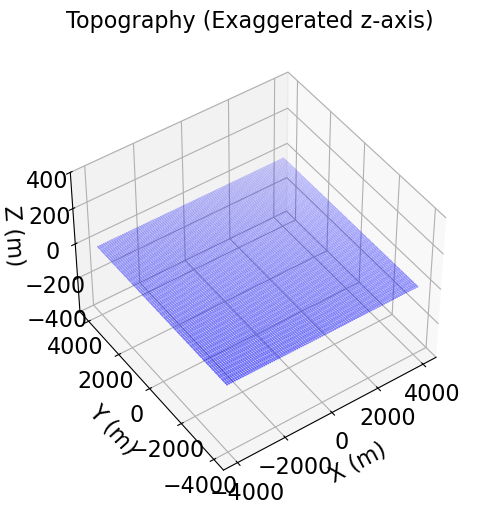

In [3]:
# Plot the topography
fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8], projection="3d")
ax.set_zlim([-400, 400])
ax.scatter3D(topo_xyz[:, 0], topo_xyz[:, 1], topo_xyz[:, 2], s=0.1, c="b")
ax.set_box_aspect(aspect=None, zoom=0.85)
ax.set_xlabel("X (m)", labelpad=10)
ax.set_ylabel("Y (m)", labelpad=10)
ax.set_zlabel("Z (m)", labelpad=10)
ax.set_title("Topography (Exaggerated z-axis)", fontsize=16, pad=-20)
ax.view_init(elev=45.0, azim=-125)

### Define Conductivity Values

Here, we define the conductivities of the structures we are modeling, along with some basic geometric parameters.
We do this early in the tutorial since the generation of a suitable mesh for NSEM depends on a-priori knowledge of the subsurface conductivity distribution.

**For the tutorial,** the Earth consists of a resistive (1e-4 S/m) horizontal layer over a more conductive basement (1e-3 S/m). In the top layer, there is a conductive block (1e-2 S/m).

:::{attention} Attention: air cell conductivities/resistivities
Note that air is defined as having a conductivity of 1e-8 S/m and not 0!!! This is necessary to ensure the linear system being solved is well-conditionned. If working with resistivity, the air cells would be given a value of 1e8 $\Omega m$.
:::

In [4]:
air_conductivity = 1e-8
host_conductivity = 1e-4
basement_conductivity = 1e-3
block_conductivity = 1e-2

# Geometry parameters
block_corner_1 = np.r_[-300., -300., -700.]
block_corner_2 = np.r_[300., 300, -200.]
basement_elevation = -1200

### Survey Geometry

Here, we define the survey geometry (e.g. locations, frequencies) used for the simulation.
This information is necessary for generating a suitable mesh, which is carried out in the following section.
At this time, however, we do not construct the SimPEG objects representing receivers, sources and the survey.
Reasons for this will be apparent later in the tutorial.

**For this tutorial**, we simulate data for several data types:

* Impedances $Z_{ij}$ for a ground magnetotelluric survey; see [Impedance](xref:simpeg#simpeg.electromagnetics.natural_source.receivers.Impedance).
* Airborne tippers and other transfer functions $T_{ij}$ that can be acquired by measuring airborne magnetic fields and magnetic fields at a base station; see [Tipper](xref:simpeg#simpeg.electromagnetics.natural_source.receivers.Tipper).
* Apparent conductivity data that can be acquire by measuring airborne magnetic fields and electric fields at a base station; see see [ApparentConductivity](xref:simpeg#simpeg.electromagnetics.natural_source.receivers.ApparentConductivity)

MT-impedance data are simulated on the Earth's surface at 10 Hz, 100 Hz and 1000 Hz. The spacing between ground MT stations is 150 m.
Airborne data are simulated at 30 Hz, 90 Hz and 360 Hz. The station spacing is 150 m and the flight height is 75 m.
The base station for simulation airborne data is located at  (-4000 m, 0 m).

In [5]:
# Define linear interpolation function for elevation
interp_fun = LinearNDInterpolator(topo_xyz[:, :2], topo_xyz[:, -1])

In [6]:
# Frequencies and locations for ground MT stations
frequencies_mt = np.r_[15., 90., 720.]
locations_xy_mt = ndgrid(
    np.arange(-1725., 1726., 150),
    np.arange(-1725., 1726., 150),
)
locations_z_mt = interp_fun(locations_xy_mt)
locations_mt = np.c_[locations_xy_mt, locations_z_mt]

In [7]:
# Frequencies and locations for airborne data
frequencies_air = np.r_[15., 90., 720.]
flight_height = 75.
locations_xy_air = ndgrid(
    np.arange(-1725., 1726., 150),
    np.arange(-1725., 1726., 150),
)
locations_z_air = interp_fun(locations_xy_air) + flight_height
locations_air = np.c_[locations_xy_air, locations_z_air]

# Remote reference location for the airborne data
location_xy_base = np.c_[4000., 0]
location_z_base = interp_fun(location_xy_base)
location_base = np.c_[location_xy_base, location_z_base]

## Design a (Tree) Mesh

The standard approach for generating meshes was provided in the [2D Simulation of Ground MT and Airborne Tipper Data](fwd_nsem_2d.ipynb) tutorial. We will take a similar approach. However, we now have a 3D problem geometry and our overall mesh discretization will need to be coarser.

**Tutorial mesh:** Here, a minimum cell thickness and cell width of 50 m is used within our survey region. We use the [refine_surface](xref:discretize#discretize.TreeMesh.refine_surface) method to refine the tree mesh based on topography within the survey region. We use the [refine_points](xref:discretize#discretize.TreeMesh.refine_points) method to refine at the locations where fields are measured. The padding is at least 6x the maximum skin depth. Visit the [tree mesh](xref:discretize#discretize.TreeMesh) API to see additional refinement methods.

:::{tip}
For a flatter surface topography as one approaches the boundary, try shifting the vertical position of the mesh so that the middle lines up with the elevation of your surface topography in the survey region.
:::

In [8]:
# Minimum skin depth
500. / np.sqrt(frequencies_mt.max() * block_conductivity)

186.33899812498248

In [9]:
# Maximum skin depth
500. / np.sqrt(frequencies_mt.min() * basement_conductivity)

4082.4829046386303

In [10]:
dh = 50.  # base cell width
dom_width_x = 64000.0  # domain width x
dom_width_y = 64000.0  # domain width x
dom_width_z = 64000.0  # domain width z
nbcx = 2 ** int(np.round(np.log(dom_width_x / dh) / np.log(2.0)) + 1)  # num. base cells x
nbcy = 2 ** int(np.round(np.log(dom_width_y / dh) / np.log(2.0)) + 1)  # num. base cells y
nbcz = 2 ** int(np.round(np.log(dom_width_z / dh) / np.log(2.0)) + 1)  # num. base cells z

# Define the base mesh with top at z = 0 m.
hx = [(dh, nbcx)]
hy = [(dh, nbcy)]
hz = [(dh, nbcz)]
mesh = TreeMesh([hx, hy, hz], x0="CCC", diagonal_balance=True)

# Shift top to maximum topography
mesh.origin = mesh.origin + np.r_[0.0, 0.0, z_topo.max()]

# Mesh refinement for core region
inds = (np.abs(topo_xyz[:, 0]) < 1750.) & (np.abs(topo_xyz[:, 1]) < 1750.)
mesh.refine_surface(
    topo_xyz[inds, :],
    padding_cells_by_level=[6, 5, 5, 5],
    finalize=False,
)

# Refine around receiver locations
pts = np.vstack(
    [locations_mt, locations_air, location_base]
)
mesh.refine_points(
    pts, padding_cells_by_level=[3, 3, 3], finalize=False
)

mesh.finalize()

In [11]:
mesh.n_cells

143018

## Define the Active Cells

Use the discretize [active_from_xyz](xref:discretize#discretize.utils.active_from_xyz) utility function to find the indices of the active cells using the mesh and surface topography. The output quantity is a ``bool`` array.

In [12]:
# Indices of the active mesh cells from topography (e.g. cells below surface)
active_cells = active_from_xyz(mesh, topo_xyz)

# number of active cells
n_active = np.sum(active_cells)

## Models and Mappings

Models and mappings for NSEM simulations were explained in the [2D Simulation of Ground MT and Airborne Tipper Data](fwd_nsem_2d.ipynb) tutorial. **For this tutorial,** the model parameters are the conductivities of all active mesh cells.

### Define the Model

The units for resistivity are $\Omega m$ and the units for conductivity are $S/m$.

In [13]:
# Define conductivity model
conductivity_model = host_conductivity * np.ones(n_active)

ind_basement = mesh.cell_centers[active_cells, -1] < basement_elevation
conductivity_model[ind_basement] = basement_conductivity

ind_block = model_builder.get_indices_block(
    block_corner_1, block_corner_2, mesh.cell_centers[active_cells, :]
)
conductivity_model[ind_block] = block_conductivity

C:\Users\devin\AppData\Local\Temp\ipykernel_22060\261260649.py:7: BreakingChangeWarning: Since SimPEG v0.25.0, the 'get_indices_block' function returns a single array with the cell indices, instead of a tuple with a single element. This means that we don't need to unpack the tuple anymore to access to the cell indices.
If you were using this function as in:

    ind = get_indices_block(p0, p1, mesh.cell_centers)[0]

Make sure you update it to:

    ind = get_indices_block(p0, p1, mesh.cell_centers)

To hide this warning, add this to your script or notebook:

    import warnings
    from simpeg.utils import BreakingChangeWarning

    warnings.filterwarnings(action='ignore', category=BreakingChangeWarning)

  ind_block = model_builder.get_indices_block(


### Define the Mapping

Our model is the electrical conductivities of all active cells in the mesh. We use the [simpeg.maps.InjectActiveCells](xref:simpeg#simpeg.maps.InjectActiveCells) mapping to map the model parameters to the mesh, and to set a constant value for all inactive cells.
 
**Important:** we set all inactive (air) cells to 1e-8 S/m instead of 0. This is done to ensure that the linear system constructed to solve the PDE for the problem is well-conditioned.

In [14]:
conductivity_map = maps.InjectActiveCells(mesh, active_cells, air_conductivity)

### Plot the Model

To show the geometry of the problem, we plot the conductivity model using the [plot_slice](xref:discretize#discretize.TreeMesh.plot_slice) method.

In [15]:
# Generate a mapping to ignore inactice cells in plot
plotting_map = maps.InjectActiveCells(mesh, active_cells, np.nan)

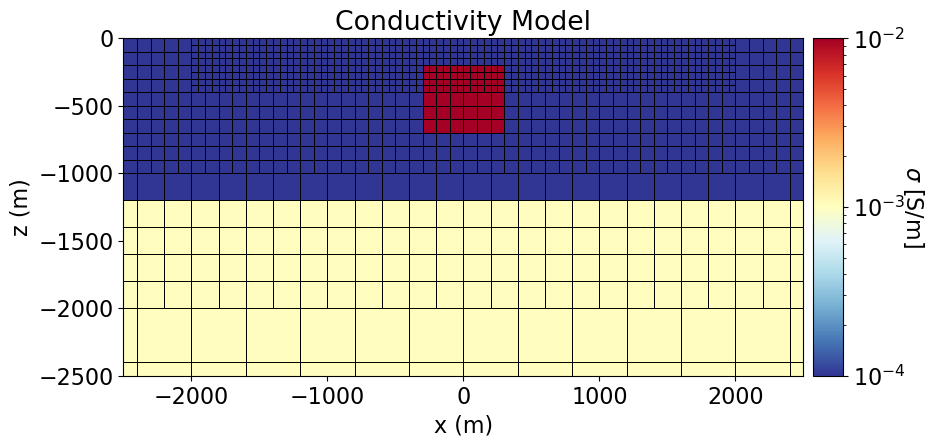

In [16]:
fig = plt.figure(figsize=(10, 4.5))

norm = LogNorm(
    vmin=conductivity_model.min(), vmax=conductivity_model.max()
)

ax1 = fig.add_axes([0.15, 0.15, 0.68, 0.75])
mesh.plot_slice(
    plotting_map * conductivity_model,
    ax=ax1,
    normal="Y",
    ind=int(len(mesh.h[1]) / 2),
    grid=True,
    pcolor_opts={"cmap": mpl.cm.RdYlBu_r, "norm": norm},
    grid_opts={"color": "k", "linewidth": 0.5}
)
ax1.set_title("Conductivity Model")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")
ax1.set_xlim([-2500, 2500])
ax1.set_ylim([z_topo.max() - 2500, z_topo.max()])

ax2 = fig.add_axes([0.84, 0.15, 0.03, 0.75])
cbar = mpl.colorbar.ColorbarBase(
    ax2, cmap=mpl.cm.RdYlBu_r, norm=norm, orientation="vertical"
)
cbar.set_label(r"$\sigma$ [S/m]", rotation=270, labelpad=15, size=16)

## Define a Background Conductivity Model

A necessary step for 2D and 3D NSEM simulation is the definition of a background conductivity model. The background conductivity model is used to compute the fields for a simplified problem geometry, which are then used to set the boundary conditions for solving the 2D or 3D problem. Here, we define a 1D background conductivity model.

**For the tutorial,** the 1D background conductivity model consists of two layers.

:::{attention}
When topography is significant, take a look at your 3D conductivity model at the boundaries. If you have padded out sufficiently, the discrete surface topography should meet the boundaries at the same elevation. This elevation should be used to denote the air-Earth interface for the 1D model.
:::

In [17]:
# Define 1D mesh using vertical discretization of the 2D/3D mesh
hz_1d = mesh.h[-1]
mesh_1d = TensorMesh([hz_1d], origin=np.array([mesh.origin[-1]]))

# Assign conductivity values
sigma_1d = air_conductivity * np.ones(mesh_1d.n_cells)
sigma_1d[mesh_1d.cell_centers < z_topo.max()] = host_conductivity
sigma_1d[mesh_1d.cell_centers < basement_elevation] = basement_conductivity

## Simulate Impedance Data

### Shift to Discrete Topography

Ground impedance data will not be modeled accurately if the receivers are modeled as living above or below the surface. It is especially problematic when receivers modeled as living in the air. Prior to simulating surface MT data, we must project the receivers from their true elevation to the surface of the discretized topography. This is done using the [shift_to_discrete_topography](xref:simpeg#simpeg.utils.shift_to_discrete_topography) utility function.

**For the tutorial,** this step isn't exactly necessary since the topography is flat and MT stations were defined directly on the surface.

In [18]:
locations_mt_shifted = shift_to_discrete_topography(
    mesh,
    locations_mt,
    active_cells,
    topo_cell_cutoff='top',
    shift_horizontal=True,
    heights=0
)

### Survey

To generate a 3D NSEM survey, the user must create and connect three types of objects:

- **receivers:** which define the locations of the NSEM fields being measured and the data type; see the [Impedance](xref:simpeg#simpeg.electromagnetics.natural_source.receivers.Impedance), [Tipper](xref:simpeg#simpeg.electromagnetics.natural_source.receivers.Tipper), [Admittance](xref:simpeg#simpeg.electromagnetics.natural_source.receivers.Admittance), and [ApparentConductivity](xref:simpeg#simpeg.electromagnetics.natural_source.receivers.ApparentConductivity) classes.
- **sources:** which defines the frequencies of the incident planewave source. For a 3D problem geometry, we use the [Fictitious](xref:simpeg#simpeg.electromagnetics.static.natural_source.source.FictitiousSource) class.
- **survey:** which uses the [survey](xref:simpeg#simpeg.electromagnetics.natural_source.Survey) class to store and organizes all of the sources and receivers.

**For this tutorial**, we simulate the real and imaginary components of impedances $Z_{xx}$, $Z_{xy}$, $Z_{yx}$ and $Z_{yy}$ for a ground MT survey.

In [19]:
source_list_mt = []  

# First loop over frequencies
for freq in frequencies_mt:

    receiver_list_mt = []

    # Next, loop over receiver types
    for orient in ['xx', 'xy', 'yx', 'yy']:
        for comp in ['real', 'imag', 'appres']:
            receiver_list_mt.append(
                nsem.receivers.Impedance(
                    locations_e=locations_mt_shifted,
                    locations_h=locations_mt_shifted,
                    orientation=orient,
                    component=comp,
                )
            )

    source_list_mt.append(
        nsem.sources.FictitiousSource(
            receiver_list=receiver_list_mt, frequency=freq,
        )
    )

survey_mt = nsem.survey.Survey(source_list_mt)

### Define the Forward Simulation

In SimPEG, the physics of the forward simulation is defined by creating an instance of an appropriate simulation class. For 3D NSEM problems, we use the [Simulation3DElectricFieldFictitious](xref:simpeg#simpeg.electromagnetics.natural_source.Simulation3DElectricFieldFictitious) class, which solves for the electric fields on mesh edges. To fully define the forward simulation, we need to connect the simulation object to:

- the mesh
- the survey
- the background conductivity model
- the mapping from the model to the mesh
- the solver

This is accomplished by setting each one of the aforementioned items as a property of the simulation object. The mapping is set using the ``sigmaMap`` keyword argument because we are working with conductivities. If working with resistivities, one would use ``rhoMap`` instead.

In [20]:
simulation_mt = nsem.simulation.Simulation3DElectricFieldFictitious(
    mesh,
    survey=survey_mt,
    sigma_background=sigma_1d,
    sigmaMap=conductivity_map,
    solver=get_default_solver()
)

### Predict and Sort MT Data

Once any simulation within SimPEG has been properly constructed, simulated data for a given model vector can be computed using the [dpred](xref:simpeg#simpeg.simulation.BaseSimulation.dpred) method.

In [21]:
dpred_mt = simulation_mt.dpred(conductivity_model)

The data vector output by the simulation is order by freqency, receiver, then location. Here, we reshape the data into a three-dimensional array for easy indexing.

In [23]:
n_comp_mt = 12  # number of receiver types
Zarray = np.reshape(dpred_mt, (len(frequencies_mt), n_comp_mt, len(locations_mt)))

### Plot Impedances

Below we plot the real and imaginary components of impedances $Z_{xy}$ and $Z_{yx}$ in units V/A. Recall that SimPEG uses a universally right-handed coordinate system with X = Easting, Y = Northing and Z = positive up and a $+i\omega t$ Fourier convention. This is different from the Northing-Easting-Down coordinate system that is common for NSEM.

As you will observe below, $Z_{xy}$ values are in the bottom-left quadrant of the complex plane (phase angle $-180 \leq \phi \leq -90$), and $Z_{yx}$ values are in the upper-right quadrant of the complex plane (phase angle $0 \leq \phi \leq 90$).

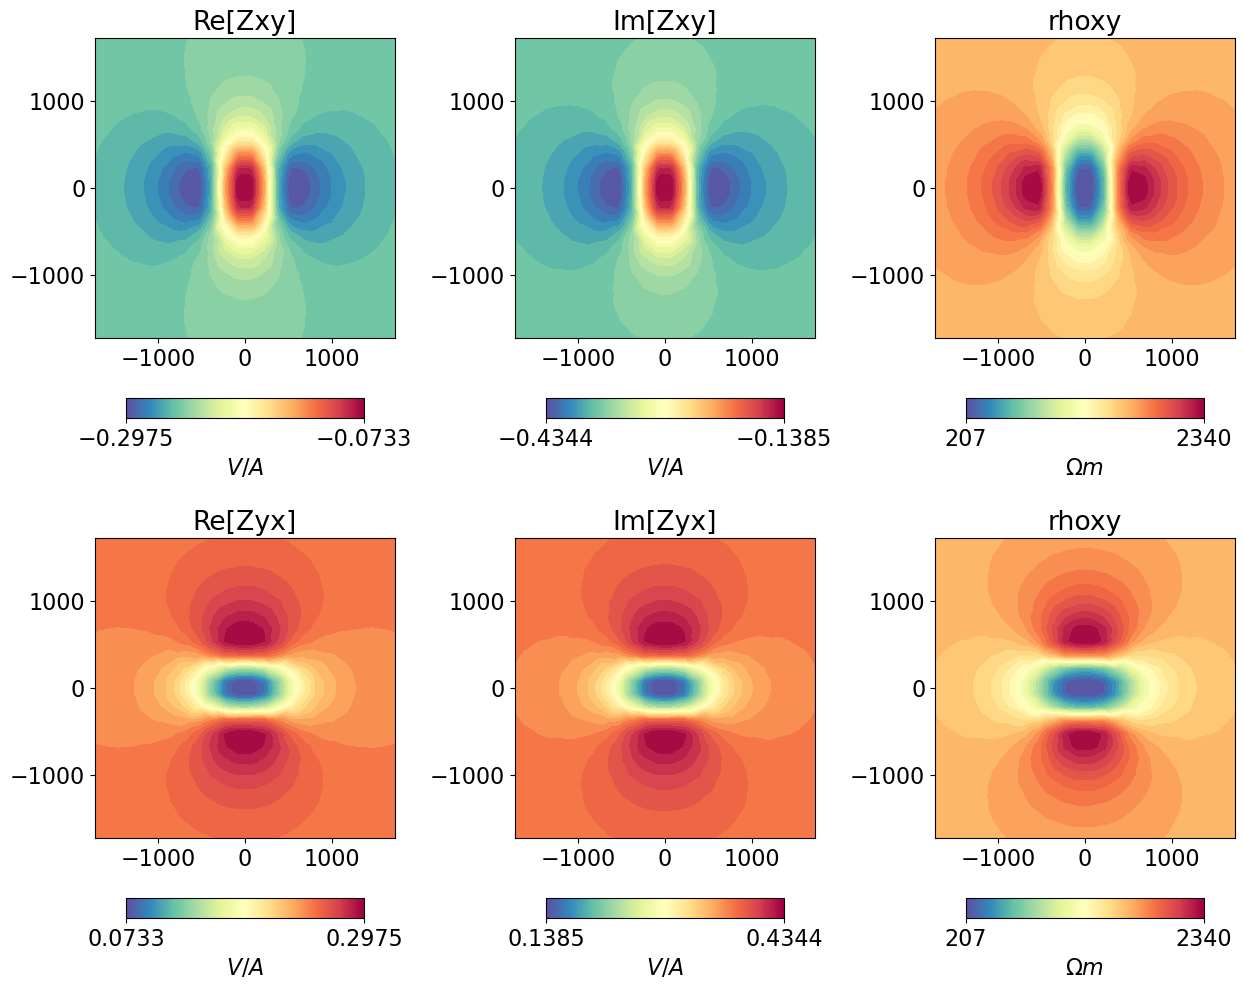

In [34]:
f_ind = 0
plotting_data = [
    Zarray[f_ind, 3, :], Zarray[f_ind, 4, :], Zarray[f_ind, 5, :],
    Zarray[f_ind, 6, :], Zarray[f_ind, 7, :], Zarray[f_ind, 8, :],
]
plotting_titles = [
    'Re[Zxy]', 'Im[Zxy]', 'rhoxy', 'Re[Zyx]', 'Im[Zyx]', 'rhoxy'
]
cmap = mpl.cm.Spectral_r

fig = plt.figure(figsize=(14, 10))
ax = 6 * [None]
cax = 6 * [None]
norm = 6 * [None]
cbar = 6 * [None]

COUNT = 0
for ii in range(2):
    for jj in range(3):
        d = plotting_data[COUNT].copy()
        norm[COUNT] = mpl.colors.Normalize(vmin=d.min(), vmax=d.max())
        ax[COUNT] = fig.add_axes([0.05 + 0.3*jj, 0.65 - 0.5*ii, 0.27, 0.3])
        plot2Ddata(
            locations_xy_air,
            d,
            ax=ax[COUNT],
            ncontour=30,
            contourOpts={"cmap": cmap, "norm": norm[COUNT]},
        )
        ax[COUNT].set_title(plotting_titles[COUNT])

        cax[COUNT] = fig.add_axes([0.1 + 0.3*jj, 0.57 - 0.5*ii, 0.17, 0.02])
        cbar[COUNT] = mpl.colorbar.ColorbarBase(
            cax[COUNT], norm=norm[COUNT], orientation="horizontal", cmap=cmap
        )
        if jj == 2:
            cbar[COUNT].set_label("$\\Omega m$")
        else:
            cbar[COUNT].set_label("$V/A$")
        cbar[COUNT].set_ticks([d.min(), d.max()])

        COUNT += 1

plt.show()

## Simulate Airborne Data

### Shift to Discrete Topography

Airborne field measurements are less influenced by the errors attributed to discrete topography compared to ground impedances. Airborne data are driven by anomalous magnetic fields while ground impedances are primarily driven by anomalous electric fields. However, users may want to preserve the original flight height of tipper measurements relative to the discrete topography. We can generated a shifted set of airborne tipper locations that preserve the original flight height using the [shift_to_discrete_topography](xref:simpeg#simpeg.utils.shift_to_discrete_topography) utility function.

**For the tutorial,** this step isn't exactly necessary since the topography is flat and MT stations were defined directly on the surface.

In [27]:
# Find the discrete topography and adds the original flight height
locations_air_shifted = shift_to_discrete_topography(
    mesh,
    locations_air,
    active_cells,
    topo_cell_cutoff='top',
    shift_horizontal=False,
    heights=flight_height
)

# Place the base station directly on the discrete topography
locations_base_shifted = np.repeat(location_base, len(locations_air), axis=0)
locations_base_shifted = shift_to_discrete_topography(
    mesh,
    locations_base_shifted,
    active_cells,
    topo_cell_cutoff='top',
    shift_horizontal=True,
    heights=0.
)

### Survey

**For this tutorial**, we simulate the real and imaginary components of transfer functions $T_{xx}$, $T_{yx}$, $T_{zx}$, $T_{xy}$, $T_{yy}$ and $T_{zy}$. We also simulate apparent resistivity data, which does not provide direct airborne conductivity measurements, but is instead named because its units are $S/m$. Data are simulated at 30 Hz, 90 Hz and 360 Hz.

In [28]:
source_list_air = []  

# Loop over all frequencies
for freq in frequencies_air:

    # Transfer functions related to tippers
    receiver_list_air = []
    for orient in ['xx', 'yx', 'zx', 'xy', 'yy', 'zy']:
        for comp in ['real', 'imag']:
            receiver_list_air.append(
                nsem.receivers.Tipper(
                    locations_h=locations_air_shifted,
                    locations_base=locations_base_shifted,
                    orientation=orient,
                    component=comp,
                )
            )

    # Apparent conductivity datum
    receiver_list_air.append(
        nsem.receivers.ApparentConductivity(
            locations_h=locations_air_shifted,
            locations_e=locations_base_shifted
        )
    )
    
    source_list_air.append(
        nsem.sources.FictitiousSource(
            receiver_list=receiver_list_air, frequency=freq,
        )
    )

survey_air = nsem.survey.Survey(source_list_air)

### Define Simulation

In [29]:
simulation_air = nsem.simulation.Simulation3DElectricFieldFictitious(
    mesh,
    survey=survey_air,
    sigmaMap=conductivity_map,
    sigma_background=sigma_1d,
    solver=get_default_solver()
)

### Predict and Sort Airborne Data

In [30]:
dpred_air = simulation_air.dpred(conductivity_model)

In [31]:
n_comp_air = 13  # number of receiver types
Tarray = np.reshape(dpred_air, (len(frequencies_air), n_comp_air, len(locations_xy_air)))

### Plot "Tipper" Data

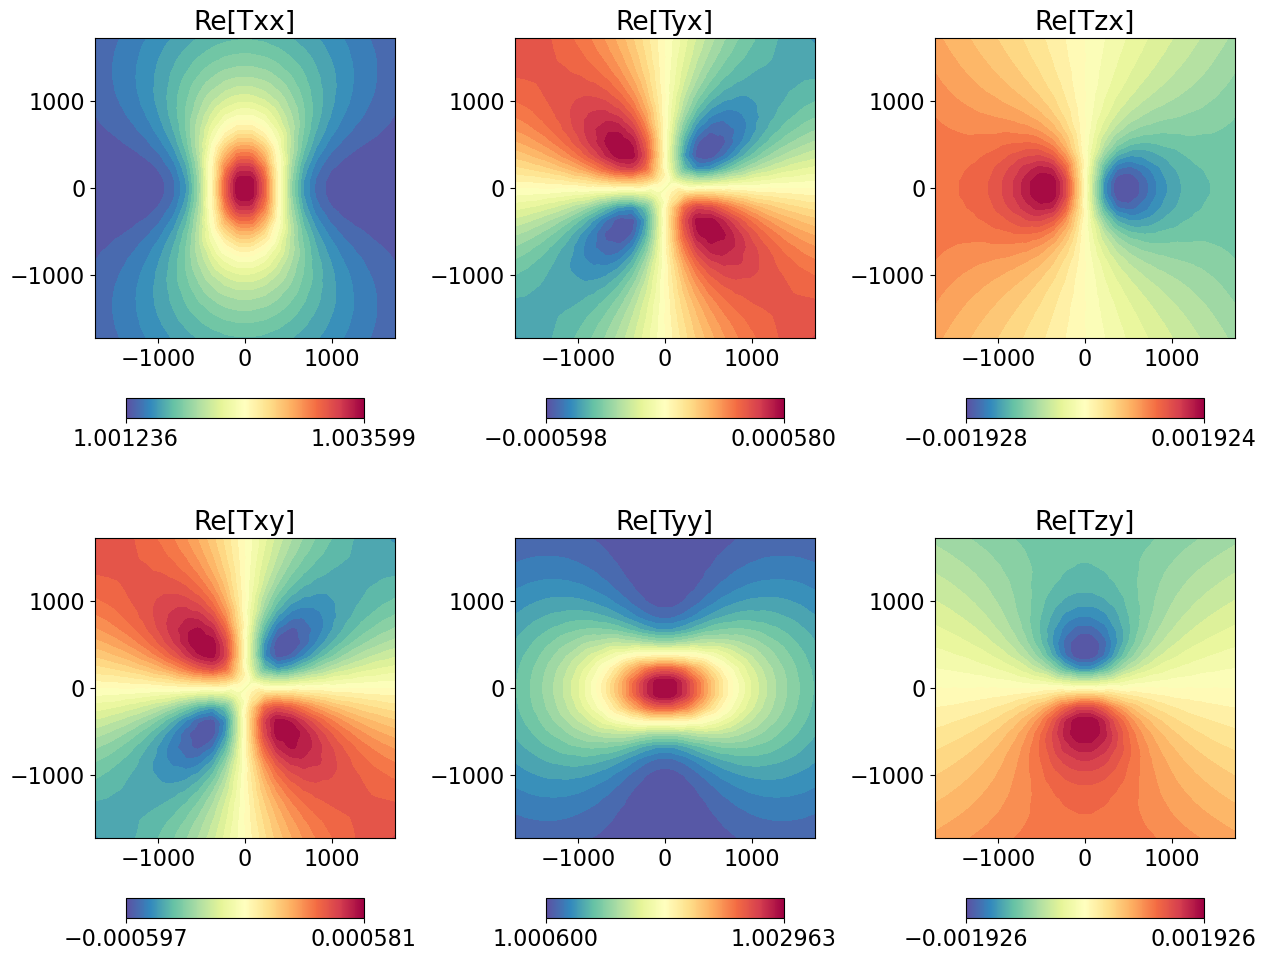

In [32]:
f_ind = 0
plotting_data = [
    Tarray[f_ind, ii, :] for ii in [0, 2, 4, 6, 8, 10]
]
plotting_titles = [
    'Re[Txx]', 'Re[Tyx]', 'Re[Tzx]', 'Re[Txy]', 'Re[Tyy]', 'Re[Tzy]'
]
cmap = mpl.cm.Spectral_r

fig = plt.figure(figsize=(14, 10))
ax = 6 * [None]
cax = 6 * [None]
norm = 6 * [None]
cbar = 6 * [None]

COUNT = 0
for ii in range(2):
    for jj in range(3):
        d = plotting_data[COUNT].copy()
        norm[COUNT] = mpl.colors.Normalize(vmin=d.min(), vmax=d.max())
        ax[COUNT] = fig.add_axes([0.05 + 0.3*jj, 0.65 - 0.5*ii, 0.27, 0.3])
        plot2Ddata(
            locations_xy_air,
            d,
            ax=ax[COUNT],
            ncontour=30,
            contourOpts={"cmap": cmap, "norm": norm[COUNT]},
        )
        ax[COUNT].set_title(plotting_titles[COUNT])

        cax[COUNT] = fig.add_axes([0.1 + 0.3*jj, 0.57 - 0.5*ii, 0.17, 0.02])
        cbar[COUNT] = mpl.colorbar.ColorbarBase(
            cax[COUNT], norm=norm[COUNT], orientation="horizontal", cmap=cmap
        )
        cbar[COUNT].set_label("")
        cbar[COUNT].set_ticks([d.min(), d.max()])

        COUNT += 1

plt.show()

### Plot Apparent Conductivities

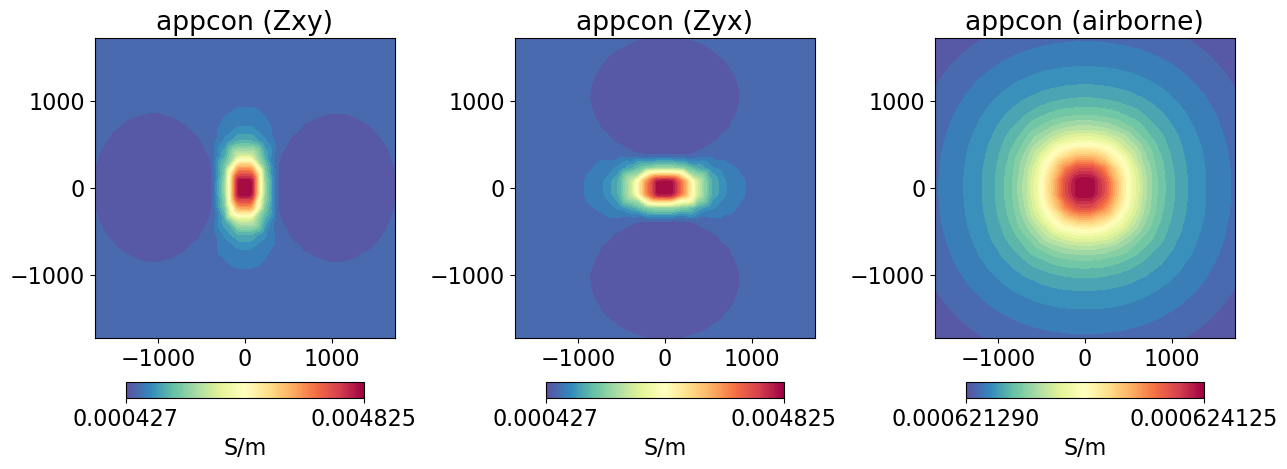

In [37]:
f_ind = 0
plotting_data = [
    Zarray[f_ind, 5, :]**-1, Zarray[f_ind, 8, :]**-1, Tarray[f_ind, -1, :]
]
plotting_titles = ['appcon (Zxy)', 'appcon (Zyx)', 'appcon (airborne)']
cmap = mpl.cm.Spectral_r

fig = plt.figure(figsize=(14, 4))
ax = 3 * [None]
cax = 3 * [None]
norm = 3 * [None]
cbar = 3 * [None]

COUNT = 0
for jj in range(3):
    d = plotting_data[COUNT].copy()
    norm[COUNT] = mpl.colors.Normalize(vmin=d.min(), vmax=d.max())
    ax[COUNT] = fig.add_axes([0.05 + 0.3*jj, 0.2, 0.27, 0.75])
    plot2Ddata(
        locations_xy_air,
        d,
        ax=ax[COUNT],
        ncontour=30,
        contourOpts={"cmap": cmap, "norm": norm[COUNT]},
    )
    ax[COUNT].set_title(plotting_titles[COUNT])

    cax[COUNT] = fig.add_axes([0.1 + 0.3*jj, 0.05, 0.17, 0.04])
    cbar[COUNT] = mpl.colorbar.ColorbarBase(
        cax[COUNT], norm=norm[COUNT], orientation="horizontal", cmap=cmap
    )
    cbar[COUNT].set_label("S/m")
    cbar[COUNT].set_ticks([d.min(), d.max()])

    COUNT += 1

plt.show()